# 03 - Merge WLASL + MS-ASL Has-Video CSV

Merges two CSV files into a unified schema:
- WLASL: `merged_datasets/universal_metadata_has_video.csv`
- MS-ASL: `MS-ASL/msasl_universal_metadata_full_all_raw_has_video.csv`

Output: `merged_datasets/universal_metadata_has_video_wlasl_msasl_merged.csv`

Labels are normalized using synonym mapping from `MS-ASL/MSASL_synonym.json`.

In [1]:
from pathlib import Path
import json
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

WLASL_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video.csv'
MSASL_CSV = PROJECT_ROOT / 'MS-ASL' / 'msasl_universal_metadata_full_all_raw_has_video.csv'
SYNONYM_JSON = PROJECT_ROOT / 'MS-ASL' / 'MSASL_synonym.json'
OUTPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video_wlasl_msasl_merged.csv'

DROP_EXACT_DUPLICATES = False
APPLY_SYNONYM_NORMALIZATION = True

TARGET_COLUMNS = [
    'label',
    'source',
    'video_path',
    'start_frame',
    'end_frame',
    'length_frames',
    'duration_sec',
    'fps',
    'signer_id',
    'has_video',
    'video_width',
    'video_height',
]

print('PROJECT_ROOT:', PROJECT_ROOT)
print('WLASL_CSV exists:', WLASL_CSV.exists(), '|', WLASL_CSV)
print('MSASL_CSV exists:', MSASL_CSV.exists(), '|', MSASL_CSV)
print('SYNONYM_JSON exists:', SYNONYM_JSON.exists(), '|', SYNONYM_JSON)
print('OUTPUT_CSV:', OUTPUT_CSV)
print('DROP_EXACT_DUPLICATES:', DROP_EXACT_DUPLICATES)
print('APPLY_SYNONYM_NORMALIZATION:', APPLY_SYNONYM_NORMALIZATION)

PROJECT_ROOT: C:\Users\Magda\source\repos\private\szum
WLASL_CSV exists: True | C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video.csv
MSASL_CSV exists: True | C:\Users\Magda\source\repos\private\szum\MS-ASL\msasl_universal_metadata_full_all_raw_has_video.csv
SYNONYM_JSON exists: True | C:\Users\Magda\source\repos\private\szum\MS-ASL\MSASL_synonym.json
OUTPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
DROP_EXACT_DUPLICATES: False
APPLY_SYNONYM_NORMALIZATION: True


In [3]:
def load_and_validate(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Missing input file for {name}: {path}')

    df = pd.read_csv(path)
    missing = [col for col in TARGET_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f'{name} CSV is missing required columns: {missing}')

    df = df[TARGET_COLUMNS].copy()

    as_text = df['has_video'].astype(str).str.strip().str.lower()
    df['has_video'] = as_text.isin(['true', '1', 'yes'])

    return df


def normalize_label(text: str) -> str:
    return str(text).strip().lower()


def build_synonym_map(path: Path) -> dict[str, str]:
    if not path.exists():
        print(f'Synonym file not found, skipping synonym normalization: {path}')
        return {}

    with path.open('r', encoding='utf-8') as f:
        groups = json.load(f)

    syn_map: dict[str, str] = {}
    for group in groups:
        if not isinstance(group, list) or len(group) == 0:
            continue

        canonical = normalize_label(group[0])
        for token in group:
            key = normalize_label(token)
            if key:
                syn_map[key] = canonical

    return syn_map


wlasl_df = load_and_validate(WLASL_CSV, 'WLASL')
msasl_df = load_and_validate(MSASL_CSV, 'MS-ASL')
synonym_map = build_synonym_map(SYNONYM_JSON)

# Prefix signer IDs by source to avoid collisions between datasets.
wlasl_df['signer_id'] = wlasl_df['signer_id'].apply(lambda x: f'wlasl_{int(x)}' if pd.notna(x) else None)
msasl_df['signer_id'] = msasl_df['signer_id'].apply(lambda x: f'msasl_{int(x)}' if pd.notna(x) else None)

print('Rows WLASL:', len(wlasl_df))
print('Rows MS-ASL:', len(msasl_df))
print('Synonym entries:', len(synonym_map))
display(wlasl_df.head(3))
display(msasl_df.head(3))

Rows WLASL: 12140
Rows MS-ASL: 16816
Synonym entries: 588


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,book,aslbrick,kaggle_dataset/videos/69241.mp4,1,75.0,75.0,2.502,29.97003,wlasl_118,True,1280.0,720.0
1,book,valencia-asl,kaggle_dataset/videos/68011.mp4,1,NaN,NaN,NaN,25.00000,wlasl_110,True,NaN,NaN
2,book,valencia-asl,kaggle_dataset/videos/68012.mp4,1,NaN,NaN,NaN,25.00000,wlasl_109,True,NaN,NaN


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,match,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_C37R_Ix8-qs...,0,83,84.0,2.767,30.0,msasl_0,True,640.0,360.0
1,fail,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_PIsUJl8BN_I...,0,74,75.0,2.960,25.0,msasl_0,True,480.0,360.0
2,book,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_J7tP98oDxqE...,0,66,67.0,2.640,25.0,msasl_0,True,480.0,360.0


In [4]:
merged_df = pd.concat([wlasl_df, msasl_df], ignore_index=True)

if APPLY_SYNONYM_NORMALIZATION:
    labels_before = merged_df['label'].astype(str).copy()
    labels_norm = labels_before.str.strip().str.lower()
    merged_df['label'] = labels_norm.map(lambda x: synonym_map.get(x, x))
    changed = (labels_before.str.strip().str.lower() != merged_df['label']).sum()
    print('Labels changed by synonym normalization:', int(changed))

if DROP_EXACT_DUPLICATES:
    before = len(merged_df)
    merged_df = merged_df.drop_duplicates().reset_index(drop=True)
    print('Dropped exact duplicates:', before - len(merged_df))

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
merged_df = merged_df.sort_values(by=['label', 'source'])
merged_df.to_csv(OUTPUT_CSV, index=False)

print('Saved merged CSV:', OUTPUT_CSV)
print('Rows merged:', len(merged_df))
print('Rows by source:')
display(merged_df['source'].value_counts(dropna=False).to_frame('count'))
print('has_video distribution:')
display(merged_df['has_video'].value_counts(dropna=False).to_frame('count'))

Labels changed by synonym normalization: 1090
Saved merged CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
Rows merged: 28956
Rows by source:


,count
source,
msasl,16816
signschool,1968
aslsearch,1875
asldeafined,1833
aslu,1823
spreadthesign,1584
asl5200,1561
startasl,623
northtexas,295


has_video distribution:


,count
has_video,
True,28956


In [5]:
display(merged_df.head(10))
display(merged_df.tail(10))

,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
14947,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,3523,3609.0,87.0,3.440,25.00,msasl_172,True,640.0,360.0
22617,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_R_ES8RZua1g...,675,734.0,60.0,1.967,30.00,msasl_40,True,568.0,320.0
25687,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_VcRx3U-HpTE...,8111,8197.0,87.0,3.583,24.00,msasl_125,True,1280.0,720.0
28075,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,4840,4881.0,42.0,1.368,29.97,msasl_26,True,1280.0,720.0
28076,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,5514,5545.0,32.0,1.034,29.97,msasl_26,True,1280.0,720.0
14010,21,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_OGjvYRhJFzM...,0,65.0,66.0,2.600,25.00,msasl_0,True,480.0,360.0
14574,21,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_oCY0mv6ShFA...,1873,1930.0,58.0,1.902,29.97,msasl_160,True,640.0,360.0
14935,21,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,1957,2055.0,99.0,3.920,25.00,msasl_172,True,640.0,360.0
16153,21,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_hFCXyB6q2nU...,2053,2141.0,89.0,2.936,29.97,msasl_124,True,640.0,360.0
18947,21,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_4b3YUL4aXbw...,1785,1835.0,51.0,1.668,29.97,msasl_22,True,640.0,360.0


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
6446,zero,asl5200,kaggle_dataset/videos/64543.mp4,1,63.0,63.0,2.520,25.000000,wlasl_9,True,NaN,NaN
6448,zero,aslsearch,kaggle_dataset/videos/64551.mp4,1,57.0,57.0,1.869,30.505723,wlasl_12,True,720.0,400.0
6450,zero,aslu,kaggle_dataset/videos/64548.mp4,1,NaN,NaN,NaN,25.000000,wlasl_5,True,NaN,NaN
6449,zero,spreadthesign,kaggle_dataset/videos/64544.mp4,1,51.0,51.0,2.040,25.000000,wlasl_1,True,320.0,240.0
6447,zero,valencia-asl,kaggle_dataset/videos/68193.mp4,1,NaN,NaN,NaN,25.000000,wlasl_109,True,NaN,NaN
21217,ﬁnish,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_Vintf-DLWq0...,615,658.0,44.0,1.439,29.878000,msasl_41,True,202.0,360.0
12625,ﬁshing,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IRa2wGdUm1A...,3378,3423.0,46.0,1.500,30.000000,msasl_41,True,202.0,360.0
12627,ﬁshing,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_IRa2wGdUm1A...,3452,3508.0,57.0,1.866,30.000000,msasl_41,True,202.0,360.0
24820,ﬂoor,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_eeHS78JyN70...,12209,12386.0,178.0,5.906,29.970000,msasl_80,True,640.0,360.0
24840,ﬂower,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_eeHS78JyN70...,20223,20410.0,188.0,6.240,29.970000,msasl_80,True,640.0,360.0


<Axes: xlabel='source'>

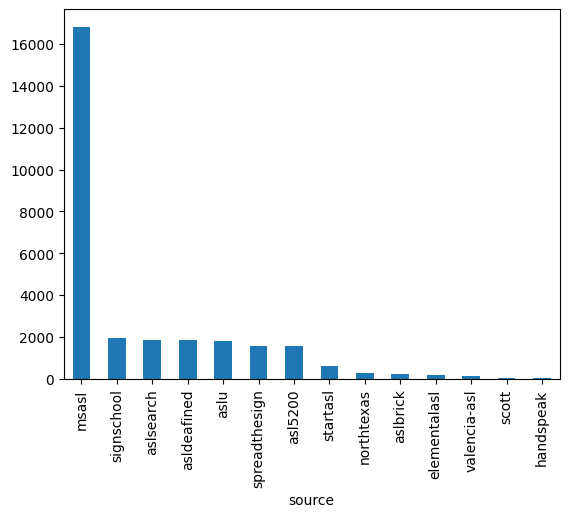

In [6]:
merged_df['source'].value_counts().plot(kind='bar')